# Regressão linear simples

### 1. Explorando a base de gorjetas

a. Na aula fizemos uma regressão de ```tip``` explicada por ```net_bill```. Carregue os pacotes e a base, crie as variáveis necessárias como na aula, e reproduza esta regressão.

b. Reproduza também o gráfico de dispersão dessas duas variáveis.

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf



# carregar a base
tips = sns.load_dataset('tips')

# criar variável net_bill (conta sem a gorjeta)
tips['net_bill'] = tips['total_bill'] - tips['tip']

# regressão
reg = smf.ols('tip ~ net_bill', data=tips).fit()

print(reg.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.333
Model:                            OLS   Adj. R-squared:                  0.330
Method:                 Least Squares   F-statistic:                     120.6
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           5.02e-23
Time:                        10:12:21   Log-Likelihood:                -375.63
No. Observations:                 244   AIC:                             755.3
Df Residuals:                     242   BIC:                             762.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.3307      0.168      7.907      0.0

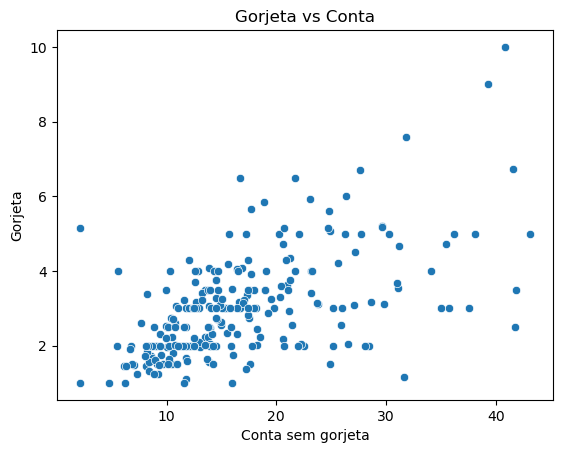

In [2]:
#B
plt.close('all')

sns.scatterplot(x='net_bill', y='tip', data=tips)

plt.xlabel('Conta sem gorjeta')
plt.ylabel('Gorjeta')
plt.title('Gorjeta vs Conta')

plt.show()

### 2. Mudança de perspectiva

Agora ajuste um modelo de regressão de ```tip_pct``` por ```net_bill```. Construa o gráfico de dispersão correspondente.

                            OLS Regression Results                            
Dep. Variable:                tip_pct   R-squared:                       0.189
Model:                            OLS   Adj. R-squared:                  0.185
Method:                 Least Squares   F-statistic:                     56.25
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           1.21e-12
Time:                        10:13:14   Log-Likelihood:                 361.93
No. Observations:                 244   AIC:                            -719.9
Df Residuals:                     242   BIC:                            -712.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2162      0.008     26.401      0.0

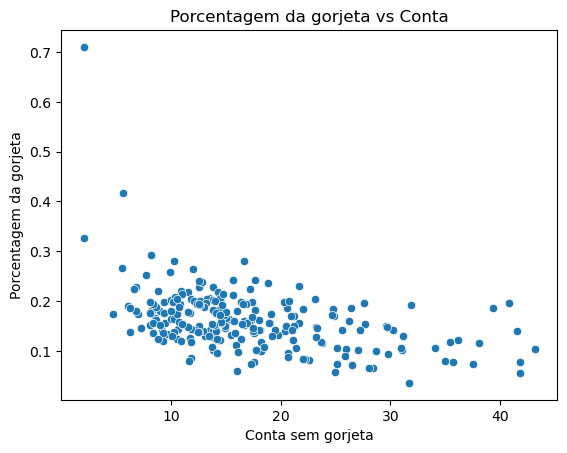

In [5]:
#Criar porcentagem da gorjeta
tips['tip_pct'] = tips['tip'] / tips['total_bill']

#Regressão

reg2 = smf.ols('tip_pct ~ net_bill', data=tips).fit()

print(reg2.summary())

#Grafico
plt.close('all')

sns.scatterplot(x='net_bill', y='tip_pct', data=tips)

plt.xlabel('Conta sem gorjeta')
plt.ylabel('Porcentagem da gorjeta')
plt.title('Porcentagem da gorjeta vs Conta')

plt.show()


### 3. Comente

Compare os dois gráficos e comente (de forma objetiva e suscinta) a relação entre eles e a diferença do ajuste. Podemos comparar diretamente os $R^2$s?

No primeiro modelo foi analisada a relação entre o valor da conta e o valor da gorjeta. Observa-se que quanto maior a conta, maior tende a ser a gorjeta.

No segundo modelo foi analisada a porcentagem da gorjeta em relação ao valor da conta. Nesse caso a relação com o valor da conta não parece tão clara.

Como as variáveis dependentes são diferentes (valor da gorjeta e porcentagem da gorjeta), não é adequado comparar diretamente os valores de R².

### 4. Ajuste do modelo em outra escala

Com o modelo no item 3, obtenha a preditiva do valor da gorjeta:
  1. obtenha o valor predito ```pred``` para ```tip_pct``` (dica, veja o atributo ```reg.fittedvalues```)
  2. obtenha o valor predito para ```tip``` como ```tip_pct * net_bill```
  3. calcule o $R^2$ do modelo para ```tip```
  4. compare esse $R^2$ com o do item 1

In [6]:
#Valor predito de tip
pred = reg2.fittedvalues

#gorjeta prevista

tip_pred = pred * tips['net_bill']


#calcular R²

from sklearn.metrics import r2_score

r2 = r2_score(tips['tip'], tip_pred)

print("R² do modelo:", r2)

R² do modelo: 0.15088205148178835


O valor predito da porcentagem da gorjeta foi utilizado para estimar o valor da gorjeta em dinheiro. O R² obtido indica o quanto o modelo consegue explicar a variação do valor das gorjetas.